In [13]:
import numpy as np
X = np.array([
    [0, 0],   # Email 1
    [0, 1],   # Email 2
    [1, 0],   # Email 3
    [1, 1]    # Email 4
])
y = np.array([0, 0, 0, 1])
X,y

(array([[0, 0],
        [0, 1],
        [1, 0],
        [1, 1]]),
 array([0, 0, 0, 1]))

In [14]:
weights=np.zeros(2)
bias=0.0
learning_rate=0.1
epochs=5
print("Weights:",weights)
print("Bias:",bias)

Weights: [0. 0.]
Bias: 0.0


In [15]:
def step_function(z):
    if z>=0:
        return 1
    else:
        return 0

In [16]:
for epoch in range(epochs):
    
    for i in range(len(X)):
        
        # Calculate weighted sum
        linear_output = np.dot(X[i], weights) + bias
        
        # Get prediction
        y_pred = step_function(linear_output)
        
        # Calculate error
        error = y[i] - y_pred
        
        # Update weights
        weights = weights + learning_rate * error * X[i]
        
        # Update bias
        bias = bias + learning_rate * error

In [17]:
print("Final Weights:", weights)
print("Final Bias:", bias)

Final Weights: [0.2 0.1]
Final Bias: -0.20000000000000004


In [18]:
print(f"Decision Boundary Equation: {weights[0]}*x1 + {weights[1]}*x2 + {bias} = 0")

Decision Boundary Equation: 0.2*x1 + 0.1*x2 + -0.20000000000000004 = 0


In [19]:
print("\nPredictions:")

for i in range(len(X)):
    linear_output = np.dot(X[i], weights) + bias
    prediction = step_function(linear_output)
    print(X[i], "→", prediction)


Predictions:
[0 0] → 0
[0 1] → 0
[1 0] → 0
[1 1] → 1


In [20]:
correct = 0
for i in range(len(X)):
    linear_output = np.dot(X[i], weights) + bias
    prediction = step_function(linear_output)
    if prediction == y[i]:
        correct += 1

accuracy = correct / len(X)
print("Accuracy:", accuracy)

Accuracy: 1.0


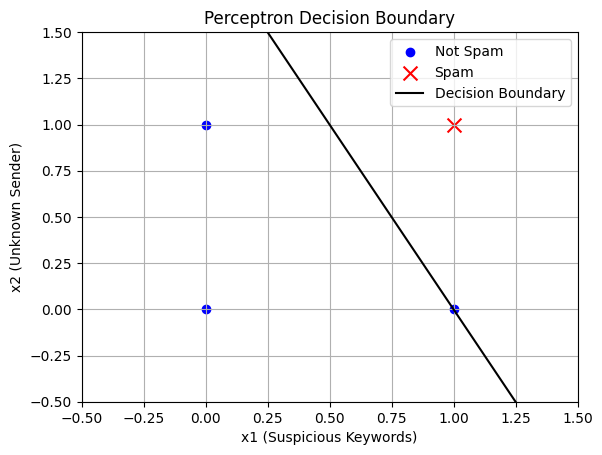

In [21]:
import matplotlib.pyplot as plt

# Separate points
X_not_spam = X[y == 0]
X_spam = X[y == 1]

# Plot
plt.scatter(X_not_spam[:, 0], X_not_spam[:, 1],
            color='blue', marker='o', label='Not Spam')

plt.scatter(X_spam[:, 0], X_spam[:, 1],
            color='red', marker='x', s=100, label='Spam')

# Decision boundary
x_values = np.linspace(-0.5, 1.5, 100)

if weights[1] != 0:
    y_values = -(weights[0] * x_values + bias) / weights[1]
    plt.plot(x_values, y_values, color='black', label='Decision Boundary')

plt.xlabel("x1 (Suspicious Keywords)")
plt.ylabel("x2 (Unknown Sender)")
plt.title("Perceptron Decision Boundary")
plt.legend()
plt.grid(True)
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.show()